In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [ ]:
df=pd.read_csv('/content/Ames_Housing.csv')

## 1.1 Dataset Overview

The Ames Housing dataset contains information about residential properties in Ames, Iowa. It contains 2,930 observations and 10 columns describing various characteristics of houses.

The target variable for this project is `SalePrice`, which represents the selling price of each house.


1.2 Check Dataset Structure

In [ ]:
df.shape

(2930, 10)

In [ ]:
df

,Overall Qual,Gr Liv Area,Total Bsmt SF,1st Flr SF,Garage Cars,Garage Area,Year Built,Full Bath,Bedroom AbvGr,SalePrice
0,6,1656,1080.0,1656,2.0,528.0,1960,1,3,215000
1,5,896,882.0,896,1.0,730.0,1961,1,2,105000
2,6,1329,1329.0,1329,1.0,312.0,1958,1,3,172000
3,7,2110,2110.0,2110,2.0,522.0,1968,2,3,244000
4,5,1629,928.0,928,2.0,482.0,1997,2,3,189900
...,...,...,...,...,...,...,...,...,...,...
2925,6,1003,1003.0,1003,2.0,588.0,1984,1,3,142500
2926,5,902,864.0,902,2.0,484.0,1983,1,2,131000
2927,5,970,912.0,970,0.0,0.0,1992,1,3,132000
2928,5,1389,1389.0,1389,2.0,418.0,1974,1,2,170000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2930 non-null   int64  
 1   Gr Liv Area    2930 non-null   int64  
 2   Total Bsmt SF  2929 non-null   float64
 3   1st Flr SF     2930 non-null   int64  
 4   Garage Cars    2929 non-null   float64
 5   Garage Area    2929 non-null   float64
 6   Year Built     2930 non-null   int64  
 7   Full Bath      2930 non-null   int64  
 8   Bedroom AbvGr  2930 non-null   int64  
 9   SalePrice      2930 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 229.0 KB


In [ ]:
df.isnull().sum()

,0
Overall Qual,0
Gr Liv Area,0
Total Bsmt SF,1
1st Flr SF,0
Garage Cars,1
Garage Area,1
Year Built,0
Full Bath,0
Bedroom AbvGr,0
SalePrice,0


In [ ]:
df.describe()

,Overall Qual,Gr Liv Area,Total Bsmt SF,1st Flr SF,Garage Cars,Garage Area,Year Built,Full Bath,Bedroom AbvGr,SalePrice
count,2930.000000,2930.000000,2929.000000,2930.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,6.094881,1499.690444,1051.614544,1159.557679,1.766815,472.819734,1971.356314,1.566553,2.854266,180796.060068
std,1.411026,505.508887,440.615067,391.890885,0.760566,215.046549,30.245361,0.552941,0.827731,79886.692357
min,1.000000,334.000000,0.000000,334.000000,0.000000,0.000000,1872.000000,0.000000,0.000000,12789.000000
25%,5.000000,1126.000000,793.000000,876.250000,1.000000,320.000000,1954.000000,1.000000,2.000000,129500.000000
50%,6.000000,1442.000000,990.000000,1084.000000,2.000000,480.000000,1973.000000,2.000000,3.000000,160000.000000
75%,7.000000,1742.750000,1302.000000,1384.000000,2.000000,576.000000,2001.000000,2.000000,3.000000,213500.000000
max,10.000000,5642.000000,6110.000000,5095.000000,5.000000,1488.000000,2010.000000,4.000000,8.000000,755000.000000


1.3 Distribution of House Prices

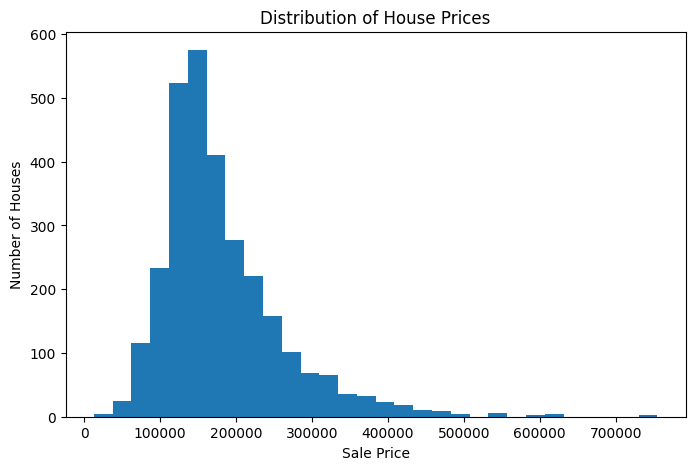

In [ ]:


plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'], bins=30)
plt.xlabel('Sale Price')
plt.ylabel('Number of Houses')
plt.title('Distribution of House Prices')
plt.show()

### Observation

* The dataset contains **2,930 houses and 10 selected columns**.
* Most selected features have **no missing values**.
* `Total Bsmt SF`, `Garage Cars`, and `Garage Area` each contain **1 missing value**.
* `SalePrice` has **no missing values**, so it can be used directly as the target variable.
* The average house sale price is approximately $180,796, while the median is $160,000.
* `SalePrice` ranges from **$12,789 to $755,000**, showing substantial variation in house prices.
* The descriptive statistics do not indicate any obvious extreme values that need to be removed at this stage. Further analysis can be performed using visualizations if required.


## 2. Feature Selection

For this house price prediction model, we selected features that are likely to have a strong relationship with the selling price of a house.

* **Overall Qual** – Represents the overall quality of the house and is expected to strongly influence its price.
* **Gr Liv Area** – Larger above-ground living areas generally have higher selling prices.
* **Total Bsmt SF** – Basement size can contribute to the overall value of a property.
* **1st Flr SF** – The size of the first floor is an important indicator of house size and value.
* **Garage Cars** – Garage capacity can influence the desirability and price of a house.
* **Garage Area** – A larger garage provides additional useful space and may increase property value.
* **Year Built** – Newer houses may have higher prices because of modern construction and features.
* **Full Bath** – The number of full bathrooms can affect the value and desirability of a house.
* **Bedroom AbvGr** – The number of bedrooms is an important characteristic when determining house value.

The target variable is **SalePrice**, which represents the selling price of the house.


## 3. Data Preprocessing

The selected features are numerical, so no categorical encoding is required. The dataset contains a small number of missing values in `Total Bsmt SF`, `Garage Cars`, and `Garage Area`.

Since these missing values are numerical, they will be replaced using the median of their respective columns. Median imputation is used because it is less affected by extreme values than the mean.


# Fill missing values:- using median imputation method

In [ ]:

df['Total Bsmt SF'] = df['Total Bsmt SF'].fillna(df['Total Bsmt SF'].median())
df['Garage Cars'] = df['Garage Cars'].fillna(df['Garage Cars'].median())
df['Garage Area'] = df['Garage Area'].fillna(df['Garage Area'].median())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2930 non-null   int64  
 1   Gr Liv Area    2930 non-null   int64  
 2   Total Bsmt SF  2930 non-null   float64
 3   1st Flr SF     2930 non-null   int64  
 4   Garage Cars    2930 non-null   float64
 5   Garage Area    2930 non-null   float64
 6   Year Built     2930 non-null   int64  
 7   Full Bath      2930 non-null   int64  
 8   Bedroom AbvGr  2930 non-null   int64  
 9   SalePrice      2930 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 229.0 KB


4.  Correlation heatmap:
*  identify features most correlated with house price

In [ ]:
df.corr(numeric_only=True)

,Overall Qual,Gr Liv Area,Total Bsmt SF,1st Flr SF,Garage Cars,Garage Area,Year Built,Full Bath,Bedroom AbvGr,SalePrice
Overall Qual,1.000000,0.570556,0.547157,0.477837,0.599392,0.563436,0.597027,0.522263,0.063291,0.799262
Gr Liv Area,0.570556,1.000000,0.444622,0.562166,0.488854,0.484865,0.241726,0.630321,0.516808,0.706780
Total Bsmt SF,0.547157,0.444622,1.000000,0.800688,0.437511,0.485458,0.407516,0.324963,0.051981,0.632164
1st Flr SF,0.477837,0.562166,0.800688,1.000000,0.439370,0.491190,0.310463,0.371584,0.106648,0.621676
Garage Cars,0.599392,0.488854,0.437511,0.439370,1.000000,0.889665,0.537033,0.478206,0.091375,0.647812
Garage Area,0.563436,0.484865,0.485458,0.491190,0.889665,1.000000,0.479903,0.407430,0.073612,0.640381
Year Built,0.597027,0.241726,0.407516,0.310463,0.537033,0.479903,1.000000,0.469406,-0.055093,0.558426
Full Bath,0.522263,0.630321,0.324963,0.371584,0.478206,0.407430,0.469406,1.000000,0.359489,0.545604
Bedroom AbvGr,0.063291,0.516808,0.051981,0.106648,0.091375,0.073612,-0.055093,0.359489,1.000000,0.143913
SalePrice,0.799262,0.706780,0.632164,0.621676,0.647812,0.640381,0.558426,0.545604,0.143913,1.000000


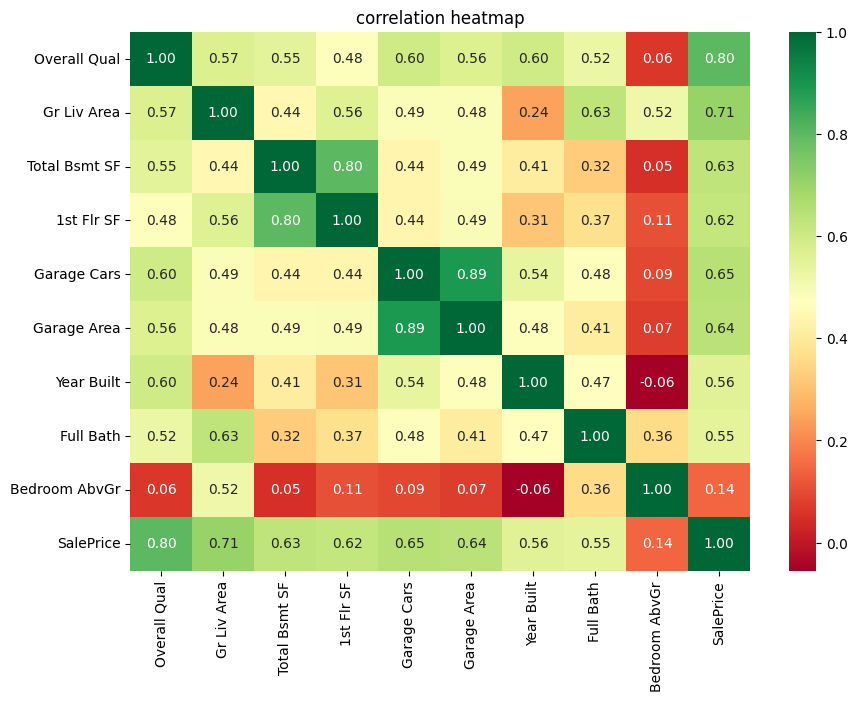

In [ ]:


plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')

plt.title('correlation heatmap')
plt.show()

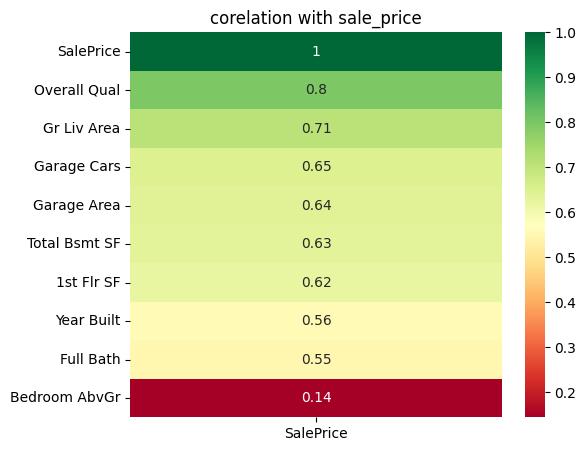

In [ ]:
corr = df.corr()['SalePrice'].sort_values(ascending=False)

plt.figure(figsize=(6,5))
sns.heatmap(corr.to_frame(), annot=True, cmap='RdYlGn')
plt.title('corelation with sale_price')
plt.show()

### Observation

The heatmap shows that `Overall Qual` and `Gr Liv Area` have the strongest positive correlation with `SalePrice`. `Garage Cars` and `Garage Area` show moderate positive correlation. The remaining features have comparatively weaker relationships with house prices.

## 5. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. The training data is used to train the Linear Regression model, while the testing data is used to evaluate its performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2344, 9)
Testing data: (586, 9)


### Observation

The dataset was split into 80% training data and 20% testing data. The training set contains 2,344 records, while the testing set contains 586 records. The training data will be used to build the model, and the testing data will be used for evaluation.

## 6. Train Linear Regression Model

A Linear Regression model is trained using the training dataset to predict house prices based on the selected features.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## 7. Model Evaluation

The Linear Regression model is evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These metrics help measure how accurately the model predicts house prices.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

#for predictionsss..
y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 1534583114.3631434
RMSE: 39173.75542838781
R² Score: 0.8085969516381306


### Observation

The Linear Regression model achieved an R² score of approximately 0.81, meaning it explains about 81% of the variation in house prices. The RMSE is approximately $39,174. indicating the typical prediction error is around $39,174. Overall, the model provides a reasonably good prediction of house prices.

## 8. Actual vs Predicted Prices

A scatter plot is used to compare the actual house prices with the prices predicted by the Linear Regression model. Points closer to the diagonal pattern indicate more accurate predictions.

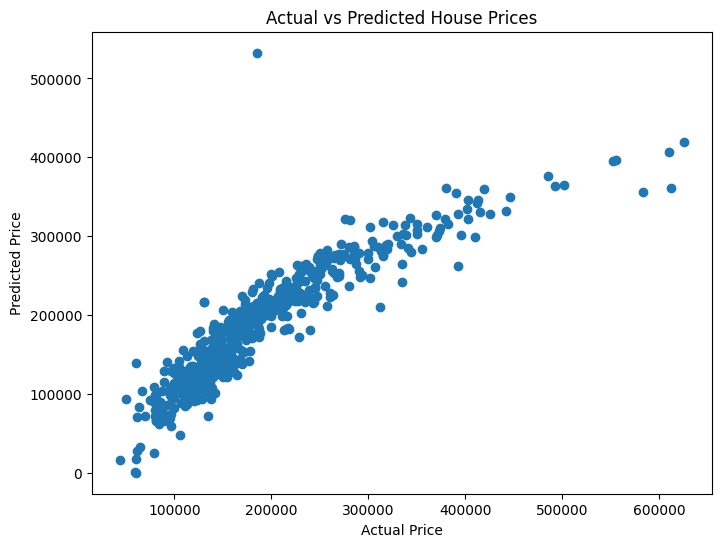

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')

plt.show()

### Observation

The scatter plot shows a strong positive relationship between actual and predicted house prices. Most points follow a clear upward pattern, indicating that the model's predictions are generally close to the actual prices. Some points show larger differences, especially for higher-priced houses.

## 9. Residual Plot

A residual plot is used to check the difference between actual and predicted prices. Ideally, the residuals should be randomly distributed around zero without a clear pattern.

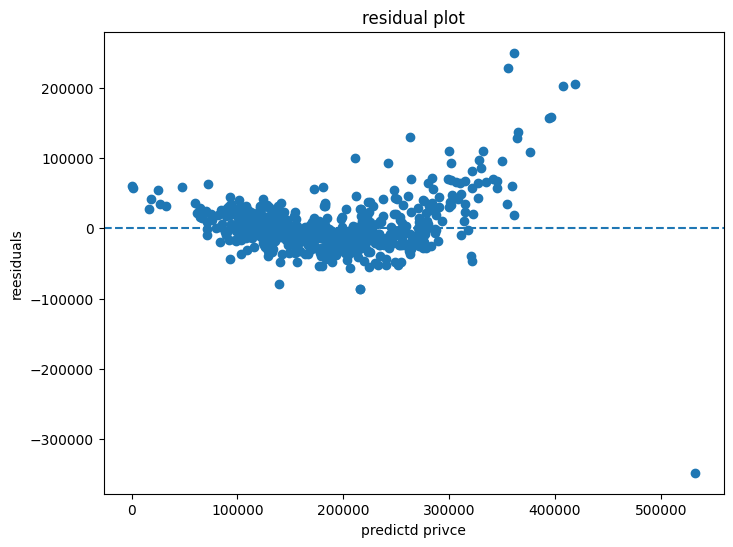

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('predictd privce')
plt.ylabel('reesiduals')
plt.title('residual plot')

plt.show()

### Observation

The residuals are mostly concentrated around zero, but they are not completely randomly distributed. The spread of residuals increases for higher predicted prices, and a few large outliers are present. This indicates that the Linear Regression model performs reasonably well but does not capture all variations in house prices.

## 10. Coefficient Analysis

The model coefficients show how each feature affects the predicted house price while keeping the other features constant. Positive coefficients indicate a positive impact on price, while negative coefficients indicate a negative impact.

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
0,Overall Qual,19902.417631
4,Garage Cars,7354.425628
6,Year Built,366.894122
1,Gr Liv Area,60.273832
5,Garage Area,21.494375
2,Total Bsmt SF,20.351593
3,1st Flr SF,9.036937
7,Full Bath,-4844.617238
8,Bedroom AbvGr,-7572.371171


### Observation
- **Overall Qual** has the highest positive coefficient (19,902.42), indicating that overall quality has the strongest positive impact on house price.
- **Garage Cars** also has a strong positive coefficient (7,354.43), suggesting that houses with greater garage capacity tend to have higher prices.
- **Year Built, Gr Liv Area, Garage Area, Total Bsmt SF, and 1st Flr SF** have positive coefficients, meaning increases in these features are generally associated with higher predicted house prices.
- **Full Bath** and **Bedroom AbvGr** have negative coefficients, indicating that, after accounting for the other features in the model, additional bathrooms or bedrooms are associated with lower predicted prices.
- Overall, **Overall Qual is the most influential feature**, while **Bedroom AbvGr has the strongest negative coefficient** among the selected features.